# Graph Neural Networks: Message Passing Toy Model

A basic message passing layer reads
$$
H^{(\ell+1)} = \sigma(\tilde D^{-1/2}\tilde A\tilde D^{-1/2} H^{(\ell)} W^{(\ell)}).
$$
We run a small two-layer GCN-style propagation and inspect feature separation.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/gnn-message-passing-toy/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/gnn-message-passing-toy") if Path("python/gnn-message-passing-toy").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Graph Neural Networks: Message Passing Toy Model**, with equations and plots designed to expose both the model and the numerical behavior.


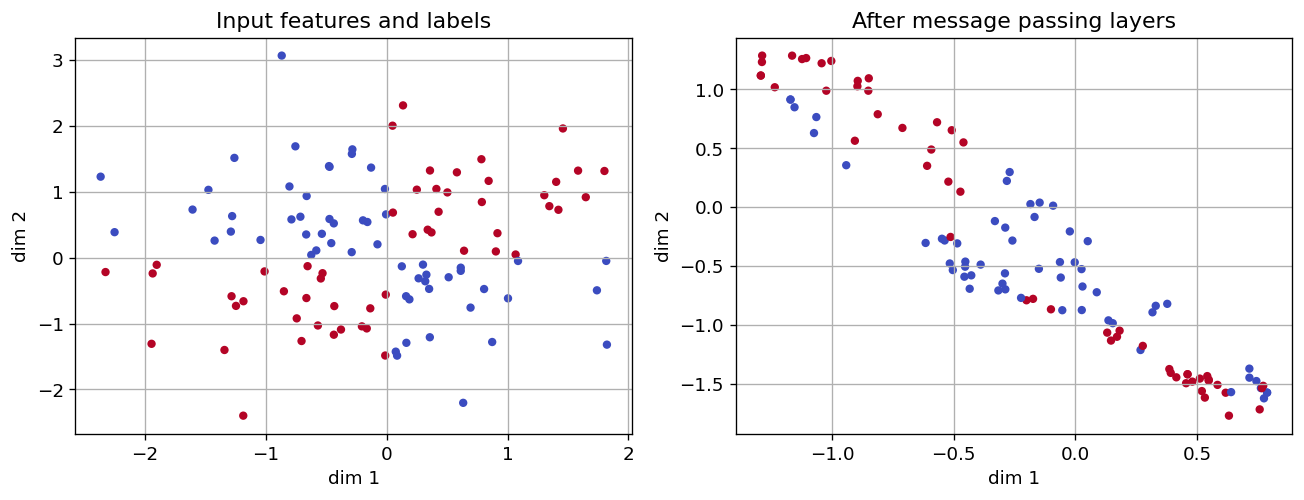

In [2]:
n = 110
X = rng.normal(size=(n, 2))
y = ((X[:, 0] * X[:, 1]) > 0).astype(int)

# Build k-NN graph
k = 8
d2 = np.sum((X[:, None, :] - X[None, :, :])**2, axis=2)
idx = np.argsort(d2, axis=1)[:, 1:k+1]
A = np.zeros((n, n))
for i in range(n):
    A[i, idx[i]] = 1
A = np.maximum(A, A.T)
A_tilde = A + np.eye(n)
D = np.diag(np.sum(A_tilde, axis=1))
Dmh = np.diag(1.0 / np.sqrt(np.diag(D) + 1e-12))
S = Dmh @ A_tilde @ Dmh

H0 = np.c_[X, np.ones(n)]
W1 = rng.normal(scale=0.5, size=(3, 8))
W2 = rng.normal(scale=0.5, size=(8, 2))
H1 = np.tanh(S @ H0 @ W1)
H2 = S @ H1 @ W2

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=16)
axes[0].set_title("Input features and labels")
axes[1].scatter(H2[:, 0], H2[:, 1], c=y, cmap="coolwarm", s=16)
axes[1].set_title("After message passing layers")
for ax in axes:
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


### References

- T. Kipf, M. Welling, "Semi-Supervised Classification with Graph Convolutional Networks", *ICLR*, 2017.
- M. Bronstein et al., "Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges", 2021.
